In [2]:
# ==========================================
# 0. SETUP & INSTALLATIONS
# ==========================================
# Install yfinance to fetch data from the cloud
!pip install -q yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set visualization style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)

print("✅ Libraries successfully imported!")




✅ Libraries successfully imported!



☁️ Fetching data from Cloud API...


/tmp/ipykernel_3552/446558000.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed


✅ Successfully downloaded 1256 rows of data for AAPL.

📊 Performing Data Analysis and Feature Engineering...


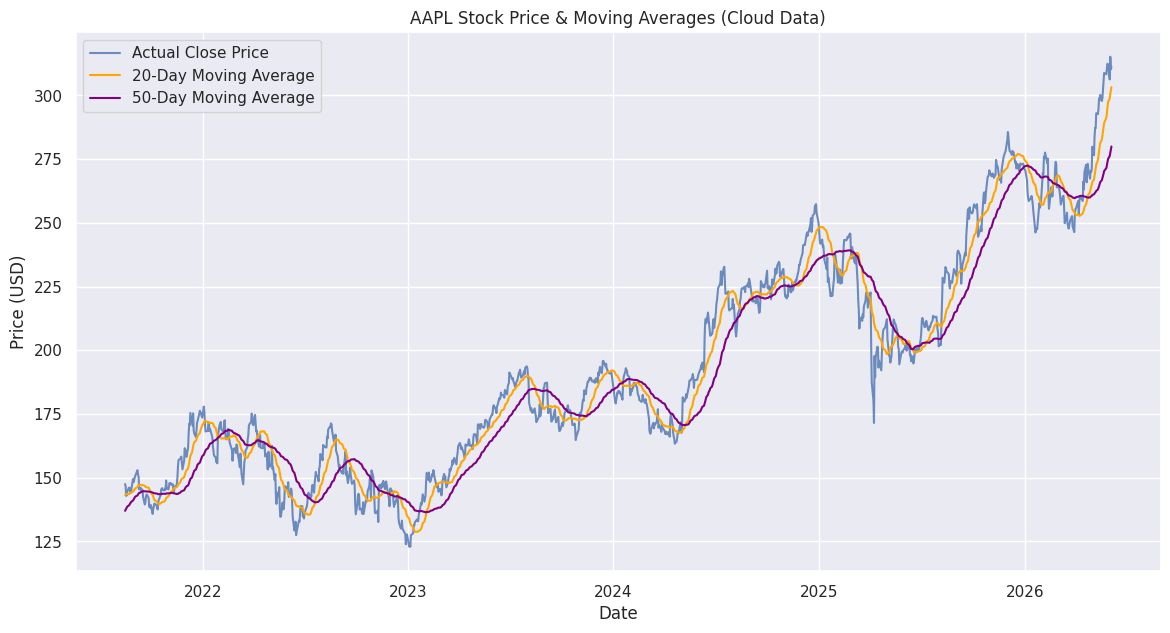

In [3]:
# ==========================================
# 1. CLOUD DATA EXTRACTION (Data Engineering)
# ==========================================
print("\n☁️ Fetching data from Cloud API...")
ticker = "AAPL" # We'll use Apple stock as an example
# Fetching the last 5 years of daily data
df = yf.download(ticker, period="5y")

# Flatten multi-index columns if yfinance returns them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

print(f"✅ Successfully downloaded {len(df)} rows of data for {ticker}.")

# ==========================================
# 2. DATA ANALYTICS & FEATURE ENGINEERING
# ==========================================
print("\n📊 Performing Data Analysis and Feature Engineering...")

# Create moving averages (Trends)
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

# Create Daily Return percentage (Volatility)
df['Daily_Return'] = df['Close'].pct_change()

# Target Variable: Next day's closing price
df['Target_Next_Close'] = df['Close'].shift(-1)

# Drop rows with NaN values generated by moving averages and shifting
df_clean = df.dropna().copy()

# VISUALIZATION: Plotting the Closing Price and Moving Averages
plt.figure()
plt.plot(df_clean.index, df_clean['Close'], label='Actual Close Price', alpha=0.8)
plt.plot(df_clean.index, df_clean['MA_20'], label='20-Day Moving Average', color='orange')
plt.plot(df_clean.index, df_clean['MA_50'], label='50-Day Moving Average', color='purple')
plt.title(f"{ticker} Stock Price & Moving Averages (Cloud Data)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


🤖 Training the Machine Learning Model...
✅ Model Trained!
📉 Mean Squared Error (MSE): 407.58
🎯 R-squared Score: 0.42 (Closer to 1.0 is better)


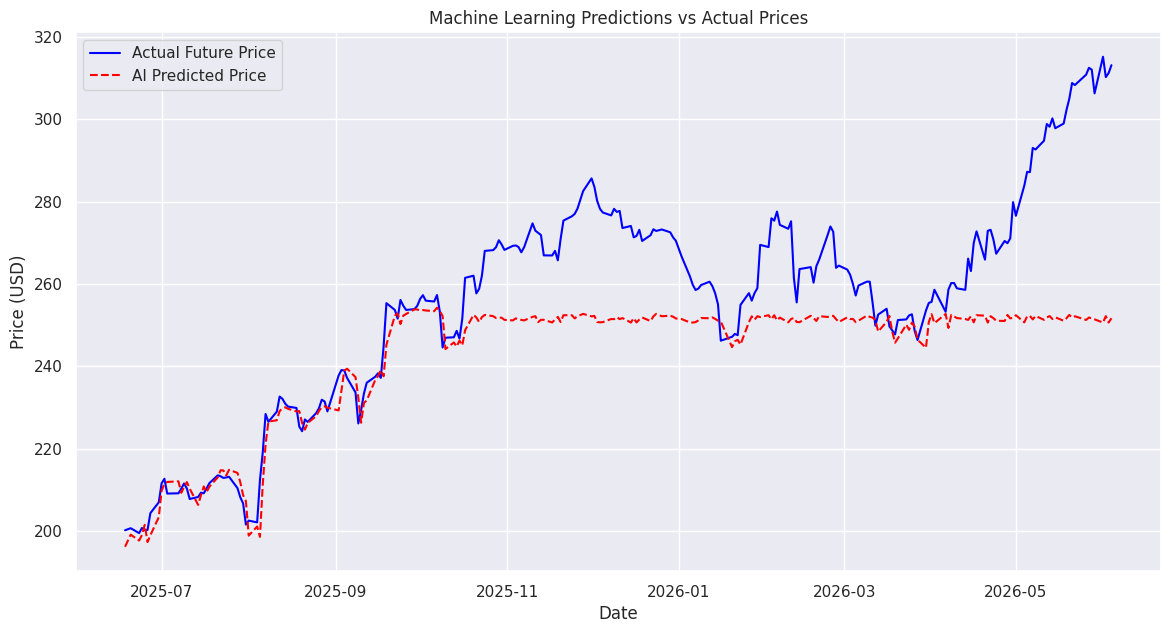

In [4]:

# ==========================================
# 3. AI / MACHINE LEARNING (Predictive Modeling)
# ==========================================
print("\n🤖 Training the Machine Learning Model...")

# Select features (Inputs) and target (Output)
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_20', 'MA_50', 'Daily_Return']
X = df_clean[features]
y = df_clean['Target_Next_Close']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize and train a Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"✅ Model Trained!")
print(f"📉 Mean Squared Error (MSE): {mse:.2f}")
print(f"🎯 R-squared Score: {r2:.2f} (Closer to 1.0 is better)")

# VISUALIZATION: Actual vs Predicted Prices
plt.figure()
plt.plot(y_test.index, y_test.values, label="Actual Future Price", color='blue')
plt.plot(y_test.index, predictions, label="AI Predicted Price", color='red', linestyle='--')
plt.title("Machine Learning Predictions vs Actual Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

